# Ejemplo de Notebook con ezdxf
Se puede usar esta libreria junto con indicaciones de terminal y mardown para hacer acciones y visualizaciones de archivos dxf en un notebook de python


In [1]:
#  
# Ejemplo geometrias basicas
#

import ezdxf

doc = ezdxf.new() 
msp = doc.modelspace()

#------------------------------------------------------
# dibujarndo dragon fractal

def dragon_fractal(puntos):
    print(f' {len(puntos)} vertices')
    respuesta = []
    Xanterior = 0
    Yanterior = 0
    Sentido   = -1
    primero   = True
    for p in puntos:
        if primero: primero = False
        else:
            # punto medio entre pto anterior 
            Xmedio   = ( Xanterior+p[0] )/2
            Ymedio   = ( Yanterior+p[1] )/2
            # vector entre pto anterior hacia pto medio
            Xvector  = Xmedio - Xanterior
            Yvector  = Ymedio - Yanterior
            # vector perpendicular
            Xperp    = -Yvector * Sentido
            Yperp    = Xvector * Sentido
            # calculando ertice fractal
            Xfractal = Xmedio + Xperp
            Yfractal = Ymedio + Yperp
            # colocando vertice fractal
            respuesta.append([Xfractal,Yfractal])
        Xanterior  = p[0]; Yanterior = p[1]
        Sentido   *= -1
        respuesta.append(p)
    return respuesta

puntos           =  [[0,0],[2,0]]
nro_iteraciones  =  15

for _ in range(nro_iteraciones): puntos = dragon_fractal(puntos)

msp.add_lwpolyline(puntos,dxfattribs={"color":6})

#------------------------------------------------------

doc.saveas("dragon.dxf")

print("Archivo DXF creado correctamente")


 2 vertices
 3 vertices
 5 vertices
 9 vertices
 17 vertices
 33 vertices
 65 vertices
 129 vertices
 257 vertices
 513 vertices
 1025 vertices
 2049 vertices
 4097 vertices
 8193 vertices
 16385 vertices
Archivo DXF creado correctamente


In [2]:
# eliminar dibujo dragon.png
from os import remove
try: remove("dragon.png")
except: pass

In [3]:
!ezdxf draw dragon.dxf --out dragon.png

loading file "dragon.dxf"...
exporting to "dragon.png"...


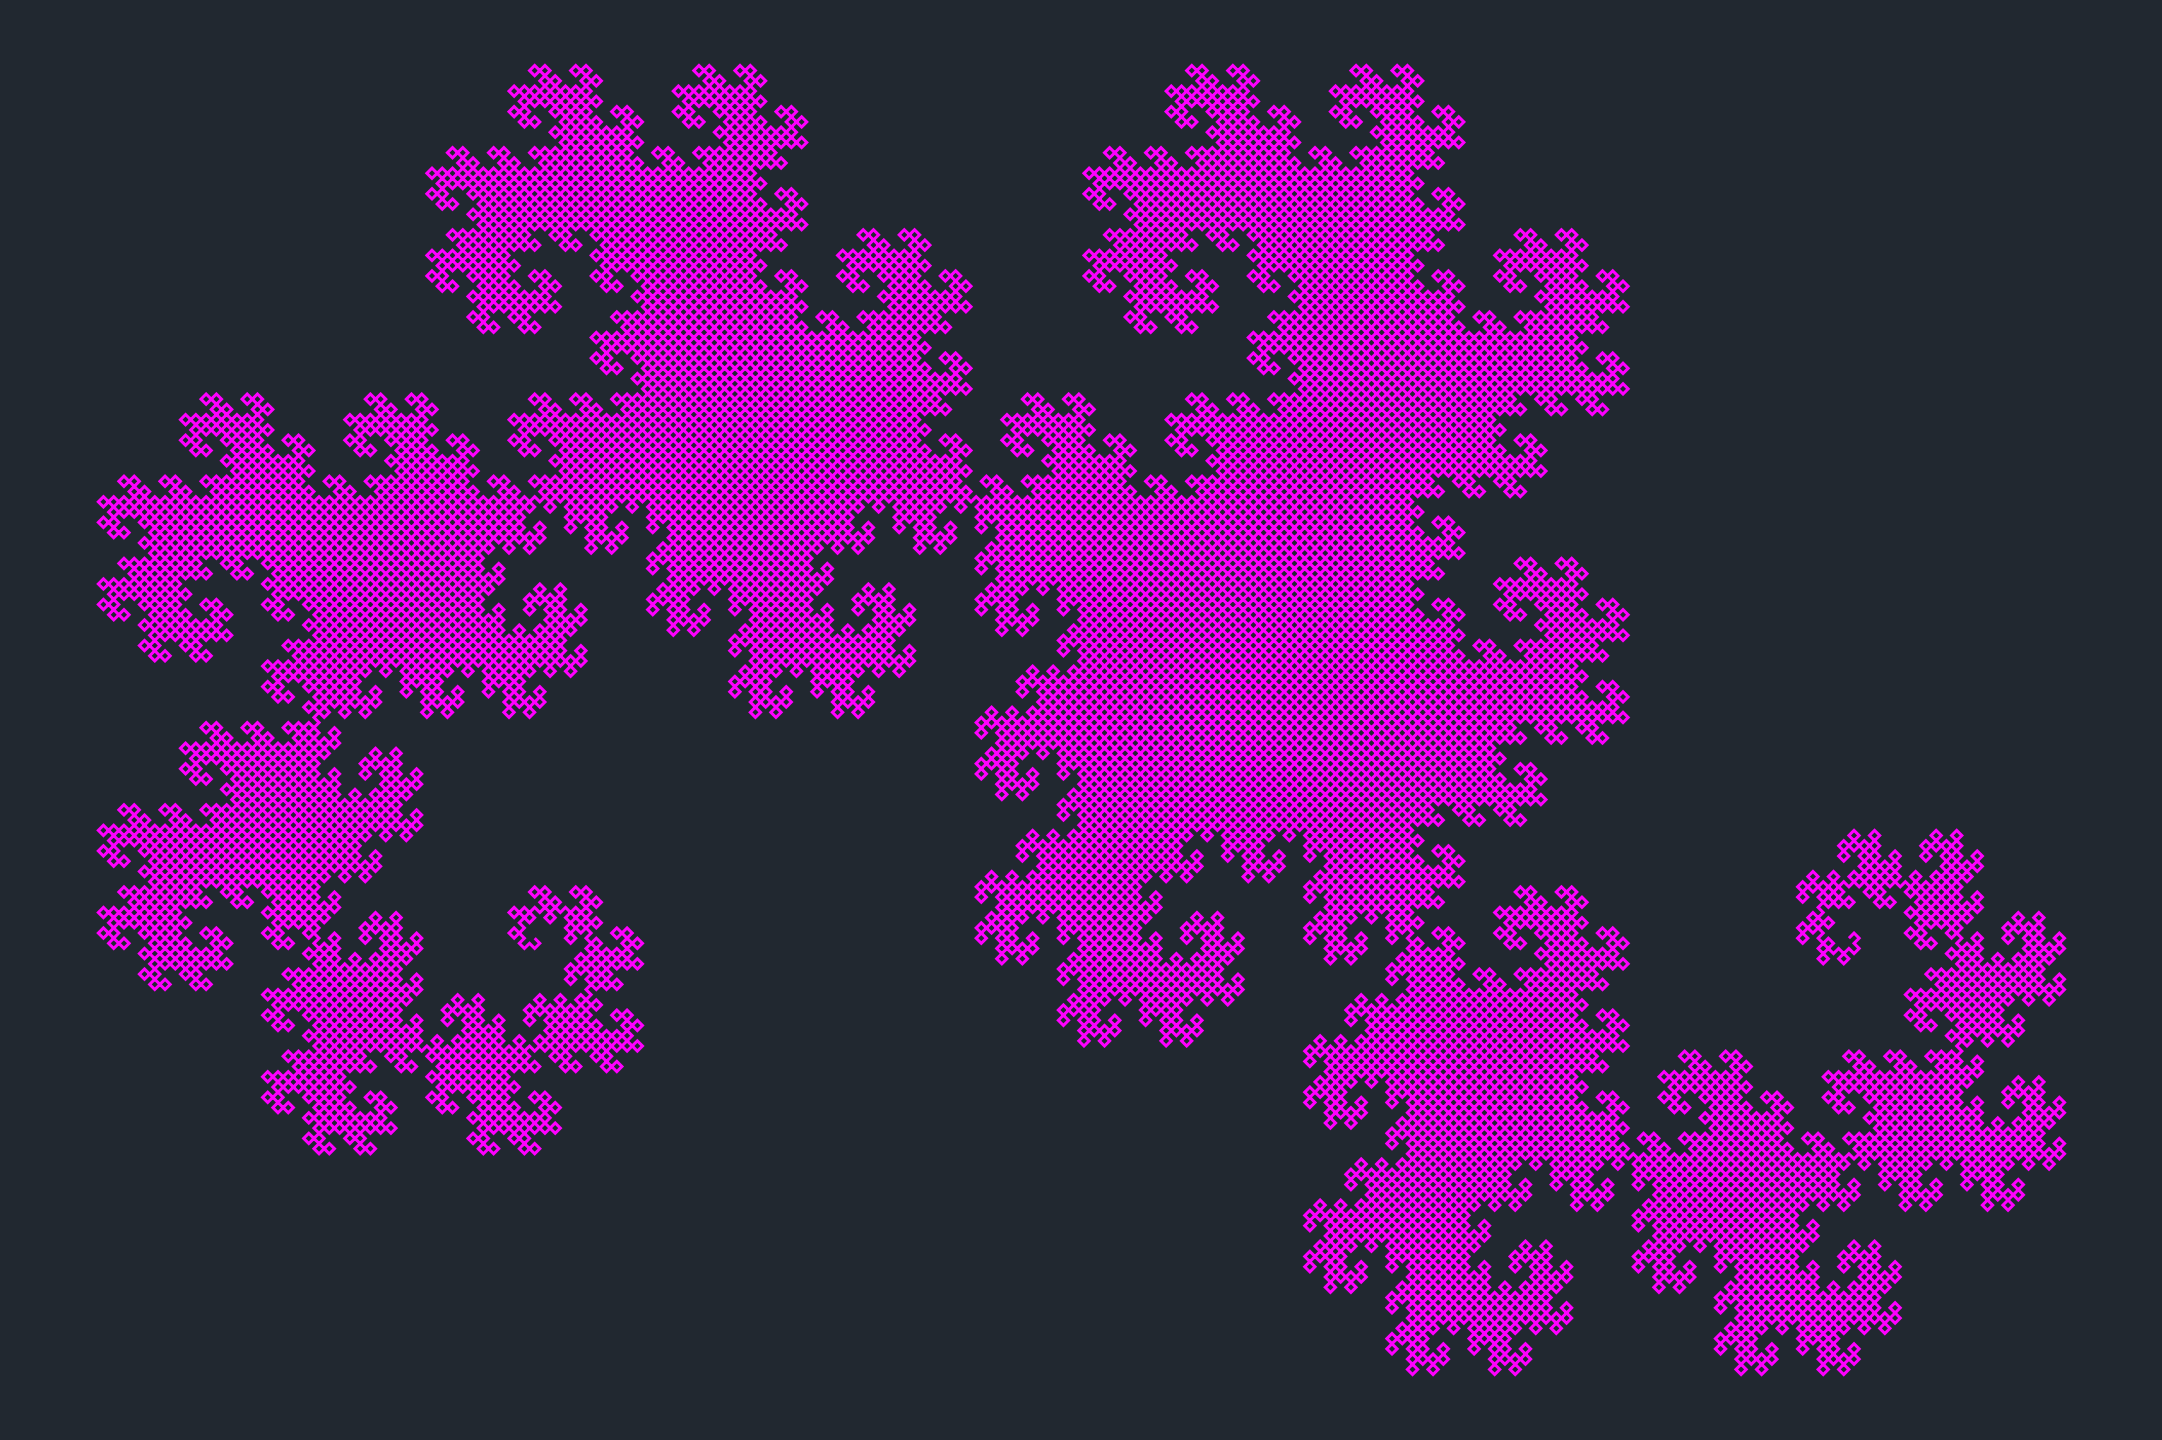

In [4]:
# Mostramos la imagen renderizada y damos acceso al dibujo DXF
from IPython.display import Image, display, HTML
display(Image(filename='dragon.png', width=600)) 
HTML('<a href="dragon.dxf" download="dragon.dxf">ARCHIVO</a>')